<a href="https://colab.research.google.com/github/MdShajalalsojib/Data-Mining-Lab/blob/main/K_Means_Clustering_003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import warnings

warnings.simplefilter("ignore")

##

##Dataset

In [2]:
df = pd.read_csv('/content/income.csv')

In [3]:
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


##**EDA**

In [4]:
df.drop('Name',axis=1,inplace=True)

In [5]:
df.head()

,Age,Income($)
0,27,70000
1,29,90000
2,29,61000
3,28,60000
4,42,150000


##Preprocessing

In [6]:
df.isnull().sum()

,0
Age,0
Income($),0


In [7]:
# normalization
df = (df-df.min())/(df.max()-df.min())

##**Visualization**

In [8]:
import matplotlib.pyplot as plt

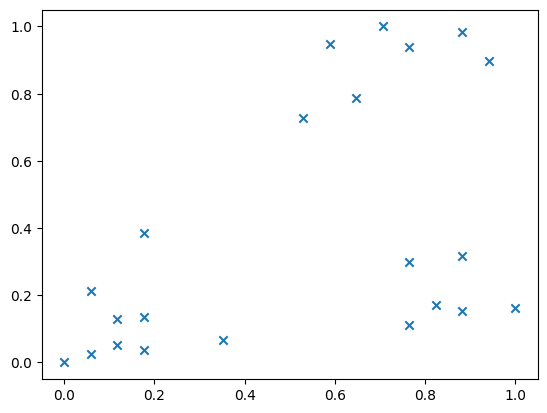

In [9]:
plt.scatter(df['Age'],df['Income($)'],marker='x')
plt.show()

##**K-Means Clustering**

In [10]:
from sklearn.cluster import KMeans

In [11]:
km = KMeans(n_clusters=3, random_state=81)

In [12]:
km.fit(df)
km.predict(df)

array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [13]:
cluster_label = km.fit_predict(df)

In [14]:
df['cluster'] = cluster_label

In [15]:
df

,Age,Income($),cluster
0,0.058824,0.213675,1
1,0.176471,0.384615,1
2,0.176471,0.136752,1
3,0.117647,0.128205,1
4,0.941176,0.897436,0
5,0.764706,0.940171,0
6,0.882353,0.982906,0
7,0.705882,1.000000,0
8,0.588235,0.948718,0
9,0.529412,0.726496,0


In [16]:
df_0 = df[df['cluster']==0]
df_1 = df[df['cluster']==1]
df_2 = df[df['cluster']==2]

In [17]:
km_center = km.cluster_centers_

In [18]:
print(km_center[0])
print(km_center[1])
print(km_center[2])

print(km_center[:,0])
print(km_center[:,1])

[0.72268908 0.8974359 ]
[0.1372549  0.11633428]
[0.85294118 0.2022792 ]
[0.72268908 0.1372549  0.85294118]
[0.8974359  0.11633428 0.2022792 ]


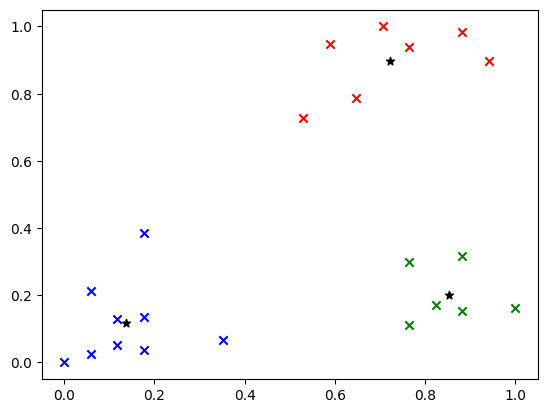

In [19]:
plt.scatter(df_0['Age'],df_0['Income($)'], marker='x', color='red')
plt.scatter(df_1['Age'],df_1['Income($)'], marker='x', color='blue')
plt.scatter(df_2['Age'],df_2['Income($)'], marker='x', color='green')
plt.scatter(km_center[:,0],km_center[:,1], marker='*', color='black')

In [20]:
km.inertia_

0.4750783498553095